## 02 – Data Cleaning & Preprocessing
**Pipeline**: Data Processing → Econometric Modeling

Notebook này thực hiện toàn bộ bước tiền xử lý dữ liệu.

**Các bước:**
1. Load & kiểm tra dữ liệu thô
2. Loại bỏ self-pairs
3. Xử lý Missing & Zero flows (biến `migration`)
4. Xử lý zero/missing trong biến độc lập
5. Outlier detection & Winsorizing
6. Log transforms
7. Fixed Effects dummies & Interaction terms
8. Correlation check
9. Kiểm tra panel balance
10. Thống kê mô tả & Lưu file

## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

SEED = 42
np.random.seed(SEED)
print('✅ Thư viện đã được import')

✅ Thư viện đã được import


In [2]:
df_raw = pd.read_csv('../data/raw/data_raw.csv')

print(f'Shape: {df_raw.shape}')
print(f'Cột ({len(df_raw.columns)}): {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (16275, 35)
Cột (35): ['iso_o', 'iso_d', 'pair_id', 'year', 'iso_o_year', 'iso_d_year', 'migration', 'gdp_org', 'gdp_des', 'gdppc_org', 'gdppc_des', 'inflation_org', 'inflation_des', 'dist', 'distcap', 'distwces', 'comlang_off', 'contig', 'colony', 'pop_org', 'pop_des', 'disaster_org', 'disaster_des', 'co2_org', 'co2_des', 'pm25_exceed_org', 'pm25_exceed_des', 'pm25_org', 'pm25_des', 'internet_use_org', 'internet_use_des', 'internet_indiv_org', 'internet_indiv_des', 'bandwidth_org', 'bandwidth_des']


,iso_o,iso_d,pair_id,year,iso_o_year,iso_d_year,migration,gdp_org,gdp_des,gdppc_org,gdppc_des,inflation_org,inflation_des,dist,distcap,distwces,comlang_off,contig,colony,pop_org,pop_des,disaster_org,disaster_des,co2_org,co2_des,pm25_exceed_org,pm25_exceed_des,pm25_org,pm25_des,internet_use_org,internet_use_des,internet_indiv_org,internet_indiv_des,bandwidth_org,bandwidth_des
0,AUS,BEL,AUS_BEL,2000,AUS2000,BEL2000,NaN,"416,167,815,092.9080","236,792,460,312.4710","26,541.6660","27,788.0918",4.4574,2.5445,"16,759.6000","16,734.7300","16,277.4500",0,0,0,19028802,10251250,4,0,18.5965,12.1907,33.8321,99.2754,7.4574,19.4897,46.7561,29.4317,0.467561,0.294317,274.3810,"6,215.9199"
1,AUS,BEL,AUS_BEL,2001,AUS2001,BEL2001,NaN,"379,629,301,675.1080","236,746,141,604.3700","27,645.8145","28,796.5801",4.4071,2.4693,"16,759.6000","16,734.7300","16,277.4500",0,0,0,19274701,10286570,7,0,18.6985,12.2426,0.0000,0.0000,7.3890,19.0777,52.6893,31.2884,0.526893,0.312884,688.4790,"25,298.4004"
2,AUS,BEL,AUS_BEL,2002,AUS2002,BEL2002,NaN,"395,788,696,012.0590","258,383,599,375.1770","29,032.4902","30,282.2891",2.9816,1.6452,"16,759.6000","16,734.7300","16,277.4500",0,0,0,19495210,10332785,3,4,18.9083,11.4677,0.0000,0.0000,7.2663,18.5923,0.0000,46.3300,0,0.4633,0.0000,"17,551.6000"


In [3]:
print('=' * 60)
print('THÔNG TIN TỔNG QUAN')
print('=' * 60)
print(f'Số quan sát       : {len(df_raw):,}')
print(f'Số cặp quốc gia   : {df_raw["pair_id"].nunique():,}')
print(f'Số quốc gia origin: {df_raw["iso_o"].nunique():,}')
print(f'Số quốc gia dest  : {df_raw["iso_d"].nunique():,}')
print(f'Khoảng thời gian  : {df_raw["year"].min()} – {df_raw["year"].max()}')
print()

miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Missing': miss, 'Tỷ lệ (%)': miss_pct})
miss_df = miss_df[miss_df['Missing'] > 0]
print('Các cột có missing values:')
print(miss_df.to_string())

THÔNG TIN TỔNG QUAN
Số quan sát       : 16,275
Số cặp quốc gia   : 651
Số quốc gia origin: 26
Số quốc gia dest  : 26
Khoảng thời gian  : 2000 – 2024

Các cột có missing values:
           Missing  Tỷ lệ (%)
migration     7150    43.9300


## Loại bỏ self-pairs (iso_o == iso_d)

Mô hình gravity chỉ xét di cư/thương mại *giữa* các quốc gia khác nhau.

In [4]:
df = df_raw.copy()

n_before = len(df)
self_pairs = df[df['iso_o'] == df['iso_d']]
print(f'Self-pairs phát hiện: {len(self_pairs)} quan sát')
if len(self_pairs) > 0:
    print('Các self-pairs:', self_pairs[['iso_o','iso_d']].drop_duplicates().values.tolist())

df = df[df['iso_o'] != df['iso_d']].copy()
print(f'\n→ Loại bỏ {n_before - len(df):,} dòng self-pairs')
print(f'→ Còn lại: {len(df):,} quan sát')

Self-pairs phát hiện: 25 quan sát
Các self-pairs: [['LAO', 'LAO']]

→ Loại bỏ 25 dòng self-pairs
→ Còn lại: 16,250 quan sát


## 3. Xử lý Missing & Zero Flows – biến `migration`

**Theo pipeline:** bước 'Làm sạch dữ liệu – Missing & Zero flows'

- **Missing flows** (NaN): cặp không có dữ liệu di cư
  - `df_nona`: loại bỏ → dùng cho OLS/FEM/REM/log-linear
  - `df_ppml`: thay = 0 → PPML xử lý được zero flows (Silva & Tenreyro 2005)
- **Zero flows**: không có quan sát nào = 0 trong bộ dữ liệu này (min = 5)


In [5]:
mig_nan  = df['migration'].isna().sum()
mig_zero = (df['migration'] == 0).sum()
mig_pos  = (df['migration'] > 0).sum()

print(f'Migration – NaN  : {mig_nan:,} ({mig_nan/len(df)*100:.1f}%)')
print(f'Migration – Zero : {mig_zero:,} ({mig_zero/len(df)*100:.1f}%)')
print(f'Migration – Dương: {mig_pos:,} ({mig_pos/len(df)*100:.1f}%)')

pairs_all_nan = df.groupby('pair_id')['migration'].apply(lambda x: x.isna().all())
print(f'\nCặp không có migration nào: {pairs_all_nan.sum()}/{df["pair_id"].nunique()}')

Migration – NaN  : 7,125 (43.8%)
Migration – Zero : 38 (0.2%)
Migration – Dương: 9,087 (55.9%)

Cặp không có migration nào: 285/650


In [6]:
# Bản 1: drop NaN → cho OLS/FEM/REM
df_nona = df.dropna(subset=['migration']).copy()
print(f'df_nona (drop NaN migration): {df_nona.shape}')

# Bản 2: NaN → 0 → cho PPML
df_ppml = df.copy()
df_ppml['migration'] = df_ppml['migration'].fillna(0)
print(f'df_ppml (NaN→0 migration)   : {df_ppml.shape}')

# Làm việc chính với df_nona
df = df_nona.copy()
print(f'\n✅ Dataset làm việc chính (df): {df.shape}')

df_nona (drop NaN migration): (9125, 35)
df_ppml (NaN→0 migration)   : (16250, 35)

✅ Dataset làm việc chính (df): (9125, 35)


## 4. Xử lý Zero/Missing trong biến độc lập

Từ Cell 4 ta thấy **chỉ `migration` bị NaN**, các biến độc lập không có missing.
Tuy nhiên một số biến có **zero values** sẽ gây lỗi khi log-transform → cần xử lý riêng.

Chiến lược:
- `internet_use`, `bandwidth`, `pm25_exceed`: zero hợp lệ về mặt kinh tế → dùng `log(x + 1)`
- `inflation`: có thể âm hoặc zero → **không log**, giữ nguyên dạng tuyến tính
- `disaster`: đếm số thiên tai, zero hợp lệ → `log(x + 1)`

In [7]:
# Kiểm tra zero values trong các biến độc lập
indep_vars = [
    'gdp_org','gdp_des','gdppc_org','gdppc_des',
    'pop_org','pop_des','dist',
    'co2_org','pm25_org','internet_use_org','bandwidth_org',
    'inflation_org','inflation_des',
    'disaster_org','disaster_des'
]

print('Kiểm tra zero values trong biến độc lập (df làm việc chính):')
print(f'{"Biến":<25} {"# Zeros":>8} {"% Zeros":>8} {"Min":>12} {"Max":>12}')
print('-' * 70)
for col in indep_vars:
    if col in df.columns:
        n_zero = (df[col] == 0).sum()
        pct = n_zero / len(df) * 100
        print(f'{col:<25} {n_zero:>8,} {pct:>7.1f}% {df[col].min():>12.2f} {df[col].max():>12.2f}')

Kiểm tra zero values trong biến độc lập (df làm việc chính):
Biến                       # Zeros  % Zeros          Min          Max
----------------------------------------------------------------------
gdp_org                         18     0.2%         0.00 29184890000000.00
gdp_des                          5     0.1%         0.00 29184890000000.00
gdppc_org                       18     0.2%         0.00    123150.17
gdppc_des                        5     0.1%         0.00    123150.17
pop_org                          0     0.0%   3857700.00 1412360000.00
pop_des                          0     0.0%   3857700.00 1412360000.00
dist                             0     0.0%       173.03     19263.88
co2_org                        365     4.0%         0.00        21.01
pm25_org                     1,649    18.1%         0.00        68.33
internet_use_org               235     2.6%         0.00        99.77
bandwidth_org                1,921    21.1%         0.00  31144400.00
inflation_org   

## 5. Outlier Detection & Winsorizing

- Dùng **Winsorizing tại 1% – 99%** cho các biến liên tục không phải dummy.
- Không winsorize: `dist`, `comlang_off`, `contig`, `colony` (bất biến / nhị phân).
- `inflation`: winsorize mạnh hơn (2.5% – 97.5%) do phân phối rất lệch.

In [8]:
from scipy.stats import mstats

# Biến cần winsorize tại 1-99%
vars_to_winsorize = [
    'gdp_org','gdp_des','gdppc_org','gdppc_des',
    'pop_org','pop_des',
    'co2_org','pm25_org',
    'internet_use_org','bandwidth_org',
    'disaster_org','disaster_des'
]

# Biến winsorize mạnh hơn
vars_winsorize_strong = ['inflation_org', 'inflation_des']

df_clean = df.copy()

for col in vars_to_winsorize:
    if col in df_clean.columns:
        df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

for col in vars_winsorize_strong:
    if col in df_clean.columns:
        df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.025, 0.025])

print('✅ Winsorizing hoàn tất')
print(f'   - {len(vars_to_winsorize)} biến: winsorize 1% – 99%')
print(f'   - {len(vars_winsorize_strong)} biến inflation: winsorize 2.5% – 97.5%')

# Tương tự cho df_ppml
df_ppml_clean = df_ppml.copy()
for col in vars_to_winsorize:
    if col in df_ppml_clean.columns:
        df_ppml_clean[col] = mstats.winsorize(df_ppml_clean[col], limits=[0.01, 0.01])
for col in vars_winsorize_strong:
    if col in df_ppml_clean.columns:
        df_ppml_clean[col] = mstats.winsorize(df_ppml_clean[col], limits=[0.025, 0.025])
print('✅ Winsorizing df_ppml hoàn tất')

✅ Winsorizing hoàn tất
   - 12 biến: winsorize 1% – 99%
   - 2 biến inflation: winsorize 2.5% – 97.5%
✅ Winsorizing df_ppml hoàn tất


## 6. Log Transforms

Theo Gravity Model chuẩn, tất cả biến liên tục dương được log-transform.

- `log(x)` cho biến chắc chắn > 0 (GDP, pop, dist)
- `log(x + 1)` cho biến có thể = 0 (disaster, internet, bandwidth, pm25_exceed)
- Giữ nguyên: `inflation` (có thể âm), các dummy nhị phân

In [9]:
# Log transform cho df_clean (OLS/FEM/REM)
log_vars = {
    # log(x) – chắc chắn dương
    'gdp_org'    : 'ln_gdp_org',
    'gdp_des'    : 'ln_gdp_des',
    'gdppc_org'  : 'ln_gdppc_org',
    'gdppc_des'  : 'ln_gdppc_des',
    'pop_org'    : 'ln_pop_org',
    'pop_des'    : 'ln_pop_des',
    'dist'       : 'ln_dist',
    'co2_org'    : 'ln_co2_org',
    'pm25_org'   : 'ln_pm25_org',
    'migration'  : 'ln_migration',
}

# log(x + 1) – có thể = 0
log1p_vars = {
    'internet_use_org' : 'ln_internet_use_org',
    'bandwidth_org'    : 'ln_bandwidth_org',
    'disaster_org'     : 'ln_disaster_org',
    'disaster_des'     : 'ln_disaster_des',
}

for raw_col, new_col in log_vars.items():
    if raw_col in df_clean.columns:
        df_clean[new_col] = np.log(df_clean[raw_col].clip(lower=1e-10))

for raw_col, new_col in log1p_vars.items():
    if raw_col in df_clean.columns:
        df_clean[new_col] = np.log1p(df_clean[raw_col])

# Tương tự cho df_ppml_clean (không log migration vì PPML dùng raw)
for raw_col, new_col in log_vars.items():
    if raw_col in df_ppml_clean.columns and raw_col != 'migration':
        df_ppml_clean[new_col] = np.log(df_ppml_clean[raw_col].clip(lower=1e-10))
for raw_col, new_col in log1p_vars.items():
    if raw_col in df_ppml_clean.columns:
        df_ppml_clean[new_col] = np.log1p(df_ppml_clean[raw_col])

log_cols_created = list(log_vars.values()) + list(log1p_vars.values())
print(f'✅ Đã tạo {len(log_cols_created)} biến log:')
for c in log_cols_created:
    print(f'   {c}')

✅ Đã tạo 14 biến log:
   ln_gdp_org
   ln_gdp_des
   ln_gdppc_org
   ln_gdppc_des
   ln_pop_org
   ln_pop_des
   ln_dist
   ln_co2_org
   ln_pm25_org
   ln_migration
   ln_internet_use_org
   ln_bandwidth_org
   ln_disaster_org
   ln_disaster_des


## 7. Fixed Effects Dummies & Interaction Terms

- **Year FE**: dummy biến năm (bỏ 1 năm làm base)
- **Origin FE / Destination FE**: dùng `iso_o`, `iso_d` làm group index trong model (không tạo dummy để tránh multicollinearity)
- **Interaction term**: `ln_gdppc_org × ln_internet_use_org` — phản ánh tác động của công nghệ điều tiết bởi thu nhập

In [10]:
# ── Year dummies ──
df_clean['year'] = df_clean['year'].astype(int)
year_dummies = pd.get_dummies(df_clean['year'], prefix='yr', drop_first=True)
df_clean = pd.concat([df_clean, year_dummies], axis=1)

df_ppml_clean['year'] = df_ppml_clean['year'].astype(int)
year_dummies_ppml = pd.get_dummies(df_ppml_clean['year'], prefix='yr', drop_first=True)
df_ppml_clean = pd.concat([df_ppml_clean, year_dummies_ppml], axis=1)

# ── Interaction terms ──
df_clean['ln_gdppc_x_internet'] = df_clean['ln_gdppc_org'] * df_clean['ln_internet_use_org']
df_ppml_clean['ln_gdppc_x_internet'] = df_ppml_clean['ln_gdppc_org'] * df_ppml_clean['ln_internet_use_org']

print(f'✅ Year dummies đã thêm: {year_dummies.shape[1]} cột (base year = {df_clean["year"].min()})')
print(f'✅ Interaction term: ln_gdppc_x_internet')
print(f'Shape df_clean    : {df_clean.shape}')
print(f'Shape df_ppml_clean: {df_ppml_clean.shape}')

✅ Year dummies đã thêm: 24 cột (base year = 2000)
✅ Interaction term: ln_gdppc_x_internet
Shape df_clean    : (9125, 74)
Shape df_ppml_clean: (16250, 73)


## 8. Correlation Check (sau log transform)

Kiểm tra lại correlation matrix với các biến đã log để phát hiện multicollinearity.

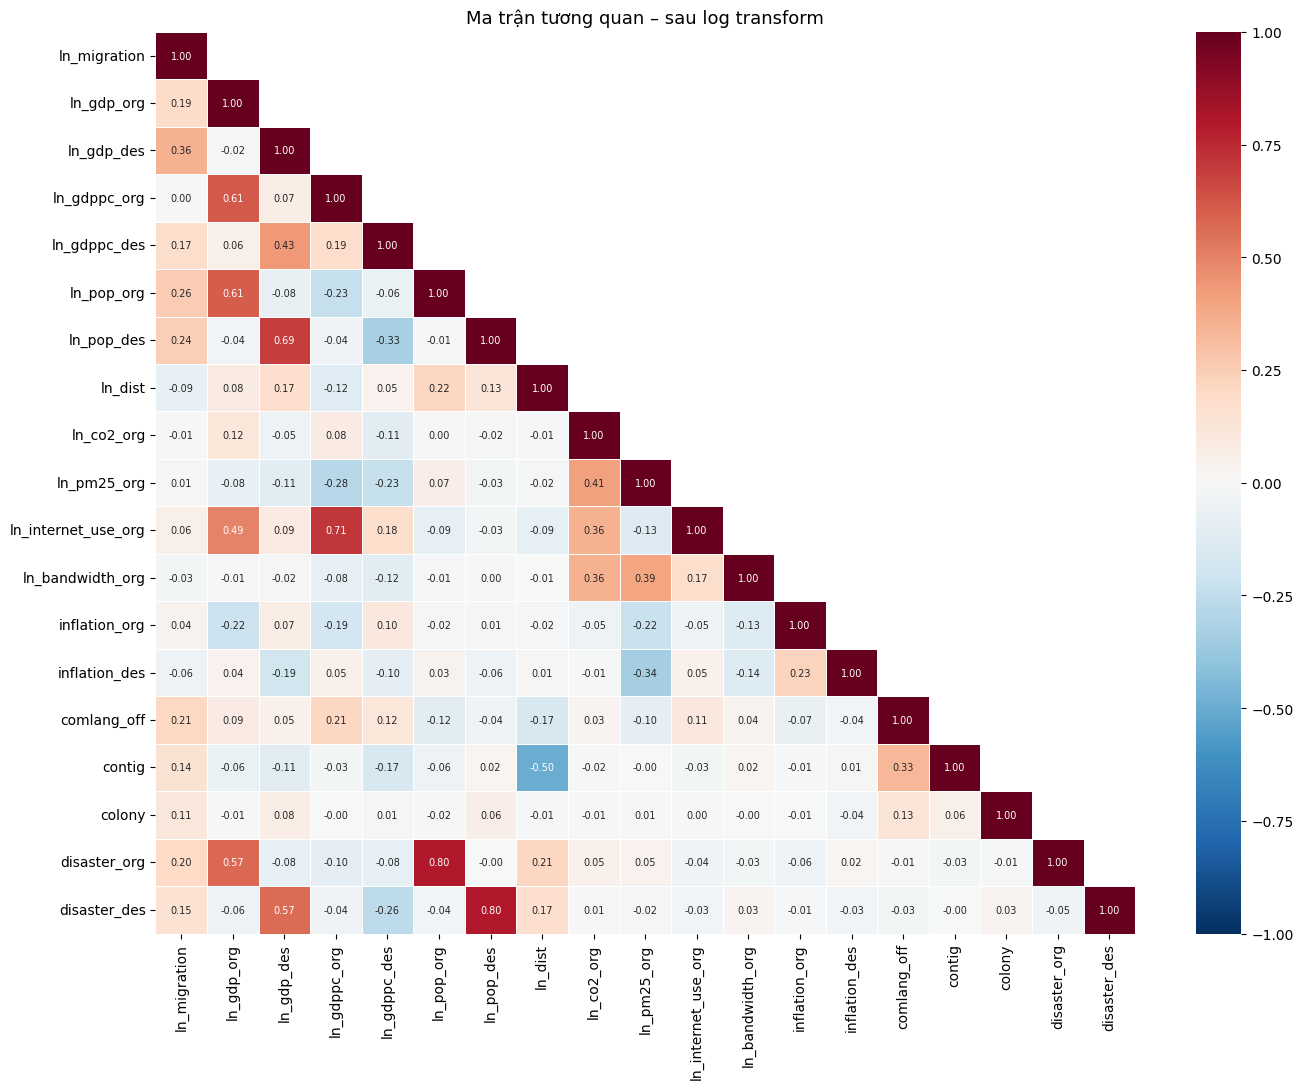

✅ Đã lưu correlation_matrix_log.png

⚠️  Cặp biến tương quan cao (|r| > 0.7):
   ln_gdppc_org ↔ ln_internet_use_org: 0.714
   ln_pop_org ↔ disaster_org: 0.797
   ln_pop_des ↔ disaster_des: 0.801


In [ ]:
main_vars = [
    'ln_migration','ln_gdp_org','ln_gdp_des',
    'ln_gdppc_org','ln_gdppc_des',
    'ln_pop_org','ln_pop_des','ln_dist',
    'ln_co2_org','ln_pm25_org',
    'ln_internet_use_org','ln_bandwidth_org',
    'inflation_org','inflation_des',
    'comlang_off','contig','colony',
    'disaster_org','disaster_des'
]
main_vars = [v for v in main_vars if v in df_clean.columns]

corr = df_clean[main_vars].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Ma trận tương quan – sau log transform', fontsize=13)
plt.tight_layout()
plt.savefig('../output/figures/correlation_matrix_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu correlation_matrix_log.png')

# Cảnh báo multicollinearity
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i, j]
        if abs(v) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(v, 3)))
if high_corr:
    print('\n⚠️  Cặp biến tương quan cao (|r| > 0.7):')
    for a, b, r in high_corr:
        print(f'   {a} ↔ {b}: {r}')
else:
    print('\n✅ Không có cặp biến nào tương quan > 0.7')

## 9. Kiểm tra Panel Balance

Panel **balanced** = mỗi cặp quốc gia có đúng T năm quan sát.
Panel **unbalanced** = số năm không đều → cần lưu ý khi chạy FEM/REM.

In [12]:
# Tạo danh sách các cặp (quốc gia 1, quốc gia 2) không phân biệt thứ tự
pairs = df[['iso_o', 'iso_d']].drop_duplicates()
pairs['sorted_pair'] = pairs.apply(lambda x: tuple(sorted([x['iso_o'], x['iso_d']])), axis=1)

# Đếm số lượng chiều cho mỗi cặp thực thể
pair_counts = pairs.groupby('sorted_pair').size()

print(f"Tổng số cặp thực thể duy nhất: {len(pair_counts)}")
print(f"Số cặp có đủ 2 chiều (A<->B): {(pair_counts == 2).sum()}")
print(f"Số cặp chỉ có 1 chiều (A->B): {(pair_counts == 1).sum()}")

Tổng số cặp thực thể duy nhất: 273
Số cặp có đủ 2 chiều (A<->B): 92
Số cặp chỉ có 1 chiều (A->B): 181


## 9. KIỂM TRA TÍNH SONG PHƯƠNG (BILATERAL)

In [13]:
# ── Kiểm tra tính song phương (bilateral symmetry) ──
print("=" * 60)
print("KIỂM TRA TÍNH SONG PHƯƠNG (BILATERAL)")
print("=" * 60)

# Tất cả cặp (iso_o, iso_d) có trong df_clean
pairs_in_data = set(zip(df_clean['iso_o'], df_clean['iso_d']))

# Kiểm tra chiều ngược lại tồn tại không
has_reverse = {(o, d): (d, o) in pairs_in_data for (o, d) in pairs_in_data}

n_total   = len(pairs_in_data)
n_both    = sum(v for v in has_reverse.values())  # đã có chiều ngược
n_one_way = n_total - n_both

print(f"Tổng số cặp (o→d) trong df_clean : {n_total}")
print(f"Có chiều ngược (d→o) tồn tại      : {n_both}  ({n_both/n_total*100:.1f}%)")
print(f"Chỉ 1 chiều (không có chiều ngược): {n_one_way} ({n_one_way/n_total*100:.1f}%)")

# Số cặp thực thể {A,B} duy nhất
unique_entity_pairs = set(frozenset([o, d]) for (o, d) in pairs_in_data)
n_bilateral_complete = sum(
    1 for p in unique_entity_pairs
    if tuple(sorted(p))[0] != tuple(sorted(p))[1]  # loại self-pair phòng ngừa
    and (list(p)[0], list(p)[1]) in pairs_in_data
    and (list(p)[1], list(p)[0]) in pairs_in_data
)
print(f"\nSố cặp thực thể {{A,B}} duy nhất        : {len(unique_entity_pairs)}")
print(f"Cặp thực thể có ĐỦ 2 chiều A↔B        : {n_bilateral_complete}")
print(f"Cặp thực thể chỉ có 1 chiều            : {len(unique_entity_pairs) - n_bilateral_complete}")

KIỂM TRA TÍNH SONG PHƯƠNG (BILATERAL)
Tổng số cặp (o→d) trong df_clean : 365
Có chiều ngược (d→o) tồn tại      : 184  (50.4%)
Chỉ 1 chiều (không có chiều ngược): 181 (49.6%)

Số cặp thực thể {A,B} duy nhất        : 273
Cặp thực thể có ĐỦ 2 chiều A↔B        : 92
Cặp thực thể chỉ có 1 chiều            : 181


In [14]:
# ── Liệt kê các cặp chỉ có 1 chiều ──
one_way_pairs = [(o, d) for (o, d), v in has_reverse.items() if not v]

df_one_way = pd.DataFrame(one_way_pairs, columns=['iso_o', 'iso_d'])
df_one_way['obs_count'] = df_one_way.apply(
    lambda r: len(df_clean[(df_clean['iso_o']==r['iso_o']) & (df_clean['iso_d']==r['iso_d'])]),
    axis=1
)
df_one_way = df_one_way.sort_values(['iso_o','iso_d'])

print(f"Danh sách {len(df_one_way)} cặp CHỈ CÓ 1 CHIỀU (không có chiều ngược):")
print(df_one_way.to_string(index=False))

Danh sách 181 cặp CHỈ CÓ 1 CHIỀU (không có chiều ngược):
iso_o iso_d  obs_count
  AUS   CAN         25
  BEL   AUS         25
  BEL   CAN         25
  BEL   CZE         25
  BEL   DNK         25
  BEL   NOR         25
  BGD   AUS         25
  BGD   BEL         25
  BGD   CAN         25
  BGD   DNK         25
  BGD   FIN         25
  BGD   HKG         25
  BGD   HUN         25
  BGD   ITA         25
  BGD   NZL         25
  BGD   SWE         25
  CHE   AUS         25
  CHE   CAN         25
  CHE   DNK         25
  CHE   FIN         25
  CHE   HKG         25
  CHE   JPN         25
  CHE   NOR         25
  CHE   NZL         25
  CHN   CAN         25
  CHN   CZE         25
  CHN   DEU         25
  CHN   HUN         25
  CZE   AUS         25
  CZE   CAN         25
  CZE   DEU         25
  CZE   DNK         25
  CZE   FIN         25
  CZE   NOR         25
  CZE   NZL         25
  DNK   CAN         25
  FIN   CAN         25
  FRA   AUS         25
  FRA   CAN         25
  FRA   CZE         25


In [15]:
# ── Quốc gia nào xuất hiện nhiều nhất trong cặp 1 chiều? ──
from collections import Counter

origins_one_way = Counter(df_one_way['iso_o'].tolist())
dests_one_way   = Counter(df_one_way['iso_d'].tolist())

print("Top quốc gia ORIGIN hay xuất hiện trong cặp 1 chiều:")
for iso, cnt in origins_one_way.most_common(10):
    print(f"  {iso}: {cnt} cặp")

print("\nTop quốc gia DEST hay xuất hiện trong cặp 1 chiều:")
for iso, cnt in dests_one_way.most_common(10):
    print(f"  {iso}: {cnt} cặp")

Top quốc gia ORIGIN hay xuất hiện trong cặp 1 chiều:
  VNM: 21 cặp
  UKR: 16 cặp
  THA: 15 cặp
  FRA: 13 cặp
  KOR: 13 cặp
  USA: 13 cặp
  NLD: 12 cặp
  BGD: 10 cặp
  LAO: 9 cặp
  CHE: 8 cặp

Top quốc gia DEST hay xuất hiện trong cặp 1 chiều:
  CAN: 24 cặp
  DNK: 15 cặp
  NOR: 15 cặp
  FIN: 14 cặp
  AUS: 12 cặp
  HUN: 12 cặp
  NZL: 11 cặp
  CZE: 10 cặp
  HKG: 8 cặp
  SWE: 8 cặp


In [16]:
# ── Đánh giá tác động lên các phương pháp ước lượng ──
print("=" * 60)
print("ĐÁNH GIÁ TÁC ĐỘNG LÊN MÔ HÌNH")
print("=" * 60)

total_obs     = len(df_clean)
bilateral_obs = df_clean.apply(
    lambda r: (r['iso_d'], r['iso_o']) in pairs_in_data, axis=1
).sum()
one_way_obs   = total_obs - bilateral_obs

print(f"Tổng quan sát df_clean          : {total_obs:,}")
print(f"Quan sát thuộc cặp có 2 chiều   : {bilateral_obs:,} ({bilateral_obs/total_obs*100:.1f}%)")
print(f"Quan sát thuộc cặp chỉ 1 chiều  : {one_way_obs:,} ({one_way_obs/total_obs*100:.1f}%)")

print("""
NHẬN XÉT:
─────────────────────────────────────────────────────────
[FEM / REM / PPML]
  → Không yêu cầu bắt buộc song phương, vẫn ước lượng được.
  → Tuy nhiên, biến ln_dist, contig, colony... đối xứng nên
    cần đảm bảo assign đúng chiều (o→d ≠ d→o về migration).

[Spatial Econometrics – SDM]
  → Ma trận W thường được xây dựng dựa trên cấu trúc mạng lưới
    song phương → cặp 1 chiều sẽ tạo W ASYMMETRIC.
  → Cần quyết định: dùng W đối xứng (max/mean 2 chiều)
    hay W có hướng (directed W).

[LASSO / BMA / ML]
  → Không bị ảnh hưởng về mặt kỹ thuật.
  → Nhưng feature importance có thể lệch nếu mẫu thiếu chiều.
─────────────────────────────────────────────────────────
PHƯƠNG ÁN XỬ LÝ (chọn 1):
  [A] Giữ nguyên toàn bộ → ghi chú panel unbalanced/asymmetric
  [B] Chỉ giữ cặp có ĐỦ 2 chiều → mất ~{one_way_obs:,} quan sát
  [C] Mirror 1 chiều: tạo dòng ngược với migration = 0 (cho PPML)
""".format(one_way_obs=one_way_obs))

# ── Tạo df_bilateral: chỉ giữ cặp có đủ 2 chiều (Phương án B) ──
bilateral_pair_set = set()
for (o, d) in pairs_in_data:
    if (d, o) in pairs_in_data:
        bilateral_pair_set.add((o, d))

df_bilateral = df_clean[
    df_clean.apply(lambda r: (r['iso_o'], r['iso_d']) in bilateral_pair_set, axis=1)
].copy()

print(f"df_bilateral (phương án B – chỉ cặp 2 chiều): {df_bilateral.shape}")
print(f"Số cặp thực thể còn lại: {df_bilateral.groupby(['iso_o','iso_d']).ngroups // 2 * 2 // 2}")

ĐÁNH GIÁ TÁC ĐỘNG LÊN MÔ HÌNH
Tổng quan sát df_clean          : 9,125
Quan sát thuộc cặp có 2 chiều   : 4,600 (50.4%)
Quan sát thuộc cặp chỉ 1 chiều  : 4,525 (49.6%)

NHẬN XÉT:
─────────────────────────────────────────────────────────
[FEM / REM / PPML]
  → Không yêu cầu bắt buộc song phương, vẫn ước lượng được.
  → Tuy nhiên, biến ln_dist, contig, colony... đối xứng nên
    cần đảm bảo assign đúng chiều (o→d ≠ d→o về migration).

[Spatial Econometrics – SDM]
  → Ma trận W thường được xây dựng dựa trên cấu trúc mạng lưới
    song phương → cặp 1 chiều sẽ tạo W ASYMMETRIC.
  → Cần quyết định: dùng W đối xứng (max/mean 2 chiều)
    hay W có hướng (directed W).

[LASSO / BMA / ML]
  → Không bị ảnh hưởng về mặt kỹ thuật.
  → Nhưng feature importance có thể lệch nếu mẫu thiếu chiều.
─────────────────────────────────────────────────────────
PHƯƠNG ÁN XỬ LÝ (chọn 1):
  [A] Giữ nguyên toàn bộ → ghi chú panel unbalanced/asymmetric
  [B] Chỉ giữ cặp có ĐỦ 2 chiều → mất ~4,525 quan sát
  [C] Mirro

## 10. Thống kê mô tả & Lưu File

Lưu 2 bản dataset đã xử lý:
- `data_clean.csv` → cho OLS / FEM / REM (log-linear)
- `data_ppml.csv` → cho PPML (raw migration, có zero)

In [17]:
# ── Thống kê mô tả ──
desc_vars = [
    'ln_migration','ln_gdp_org','ln_gdp_des',
    'ln_gdppc_org','ln_gdppc_des',
    'ln_pop_org','ln_pop_des','ln_dist',
    'ln_co2_org','ln_pm25_org',
    'ln_internet_use_org','ln_bandwidth_org',
    'inflation_org','inflation_des',
    'comlang_off','contig','colony',
    'disaster_org','disaster_des'
]
desc_vars = [v for v in desc_vars if v in df_clean.columns]

desc = df_clean[desc_vars].describe().T[['count','mean','std','min','25%','50%','75%','max']]
desc.columns = ['N','Mean','Std','Min','P25','Median','P75','Max']
print('=== THỐNG KÊ MÔ TẢ – df_clean (log-transformed) ===')
print(desc.round(3).to_string())

# ── Lưu file ──
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_csv('../data/processed/data_clean.csv', index=False)
df_ppml_clean.to_csv('../data/processed/data_ppml.csv', index=False)

print(f'\n✅ Đã lưu:')
print(f'   ../data/processed/data_clean.csv  → {df_clean.shape}')
print(f'   ../data/processed/data_ppml.csv   → {df_ppml_clean.shape}')

=== THỐNG KÊ MÔ TẢ – df_clean (log-transformed) ===
                             N    Mean    Std      Min     P25  Median     P75     Max
ln_migration        9,125.0000  8.9820 2.9800 -23.0260  7.6450  9.1790 10.5760 14.7280
ln_gdp_org          9,125.0000 26.9720 1.9190  21.7300 25.8840 26.8850 28.2660 30.7960
ln_gdp_des          9,125.0000 27.0950 1.5950  22.3420 26.1300 26.9030 28.1920 30.6070
ln_gdppc_org        9,125.0000  9.9760 1.0090   7.3760  9.2590 10.3650 10.7380 11.3600
ln_gdppc_des        9,125.0000 10.3280 0.8170   7.4790 10.2310 10.5480 10.8190 11.4220
ln_pop_org          9,125.0000 17.4770 1.5420  15.2750 16.1310 17.6860 18.3100 21.0670
ln_pop_des          9,125.0000 16.9920 1.5310  15.2350 15.7490 16.4740 17.9150 21.0660
ln_dist             9,125.0000  8.2690 1.1370   5.1530  7.2850  8.8120  9.1160  9.8660
ln_co2_org          9,125.0000  0.6250 4.9410 -23.0260  1.2650  1.8360  2.2800  2.9940
ln_pm25_org         9,125.0000 -1.8070 9.9800 -23.0260  1.9910  2.6850  3.1880